In [2]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Product-Demand-Inventory-Analytics-Dataset.csv")

In [4]:
df

,Category,Product,Warehouse,Zip,Date,Time,Order Demand,Value
0,TBOX,TBOX,Berkeley,94701,27/08/2018,23:56:00,1000,504.010
1,Worksuite 1000,Tribes,Berkeley,94701,18/07/2018,23:55:00,1000,147.330
2,TBOX,TBOX S3,Berkeley,94701,14/09/2018,23:50:00,1000,185.250
3,Worksuite 1000,Sociplace,Berkeley,94701,05/10/2018,23:45:00,1000,255.000
4,TBOX,TBOX S3,Berkeley,94701,15/06/2018,23:35:00,1000,185.250
...,...,...,...,...,...,...,...,...
49995,Worksuite 1000,ShareIt,Berkeley,94701,15/02/2019,20:33:00,1,197.110
49996,Worksuite 1000,SlidePoint,Berkeley,94701,22/07/2019,15:45:00,1,364.390
49997,Worksuite 1000,DoneIt,Berkeley,94701,04/07/2019,14:20:00,1,63.260
49998,Worksuite 1000,Streamer,Berkeley,94701,24/05/2018,16:30:00,1,256.554


In [5]:
df.head()

,Category,Product,Warehouse,Zip,Date,Time,Order Demand,Value
0,TBOX,TBOX,Berkeley,94701,27/08/2018,23:56:00,1000,504.01
1,Worksuite 1000,Tribes,Berkeley,94701,18/07/2018,23:55:00,1000,147.33
2,TBOX,TBOX S3,Berkeley,94701,14/09/2018,23:50:00,1000,185.25
3,Worksuite 1000,Sociplace,Berkeley,94701,05/10/2018,23:45:00,1000,255.00
4,TBOX,TBOX S3,Berkeley,94701,15/06/2018,23:35:00,1000,185.25


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Category      50000 non-null  str    
 1   Product       50000 non-null  str    
 2   Warehouse     50000 non-null  str    
 3   Zip           50000 non-null  int64  
 4   Date          50000 non-null  str    
 5   Time          50000 non-null  str    
 6   Order Demand  50000 non-null  int64  
 7   Value         50000 non-null  float64
dtypes: float64(1), int64(2), str(5)
memory usage: 3.1 MB


In [64]:
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)

In [65]:
df[df.duplicated(keep=False)]

,Category,Product,Warehouse,Zip,Date,Time,Order Demand,Value,Year
2,TBOX,TBOX S3,Berkeley,94701,2018-09-14,23:50:00,1000,185.25,2018
3,Worksuite 1000,Sociplace,Berkeley,94701,2018-10-05,23:45:00,1000,255.00,2018
5,Worksuite 1000,SlidePoint,Berkeley,94701,2018-07-18,23:55:00,1000,364.39,2018
7,Worksuite 1000,Whathype,Berkeley,94701,2018-08-20,23:30:00,1000,396.33,2018
8,Worksuite 1000,EmailOut,Berkeley,94701,2018-07-26,23:30:00,1000,91.09,2018
...,...,...,...,...,...,...,...,...,...
49991,TBOX,TBOX,Berkeley,94701,2019-07-19,14:00:00,1,504.01,2019
49993,Worksuite 1000,Wordwrite,Berkeley,94701,2019-10-04,11:00:00,1,467.22,2019
49994,BI Stack,BI Visualiser,Berkeley,94701,2018-06-25,22:45:00,1,128.54,2018
49995,Worksuite 1000,ShareIt,Berkeley,94701,2019-02-15,20:33:00,1,197.11,2019


In [66]:
df.isna().sum()


Category        0
Product         0
Warehouse       0
Zip             0
Date            0
Time            0
Order Demand    0
Value           0
Year            0
dtype: int64

In [67]:
df.dtypes

Category                   str
Product                    str
Warehouse                  str
Zip                      int64
Date            datetime64[us]
Time                       str
Order Demand             int64
Value                  float64
Year                     int32
dtype: object

In [68]:
df["Time"].head()

0    23:56:00
1    23:55:00
2    23:50:00
3    23:45:00
4    23:35:00
Name: Time, dtype: str

In [69]:
df[df["Date"].dt.year == 2019]

,Category,Product,Warehouse,Zip,Date,Time,Order Demand,Value,Year
694,Worksuite 1000,SlidePoint,Berkeley,94701,2019-02-12,21:00:00,1000,364.39,2019
697,Worksuite 1000,VideoRight,Berkeley,94701,2019-02-04,21:00:00,1000,601.56,2019
698,BI Stack,BI Visualiser,Berkeley,94701,2019-01-15,21:00:00,1000,128.54,2019
701,Worksuite 1000,PublishIt,Berkeley,94701,2019-01-22,21:00:00,1000,621.87,2019
702,TBOX,TBOX,Berkeley,94701,2019-01-17,21:00:00,1000,504.01,2019
...,...,...,...,...,...,...,...,...,...
49993,Worksuite 1000,Wordwrite,Berkeley,94701,2019-10-04,11:00:00,1,467.22,2019
49995,Worksuite 1000,ShareIt,Berkeley,94701,2019-02-15,20:33:00,1,197.11,2019
49996,Worksuite 1000,SlidePoint,Berkeley,94701,2019-07-22,15:45:00,1,364.39,2019
49997,Worksuite 1000,DoneIt,Berkeley,94701,2019-07-04,14:20:00,1,63.26,2019


In [70]:
df["Category"].nunique()

3

In [71]:
# demand across time

In [95]:
df["Year"] = df["Date"].dt.year

yearly_demand = (
    df.groupby("Year")["Order Demand"]
      .sum()
      .reset_index()
)

print(yearly_demand)

   Year  Order Demand
0  2018    1038212810
1  2019     648948337


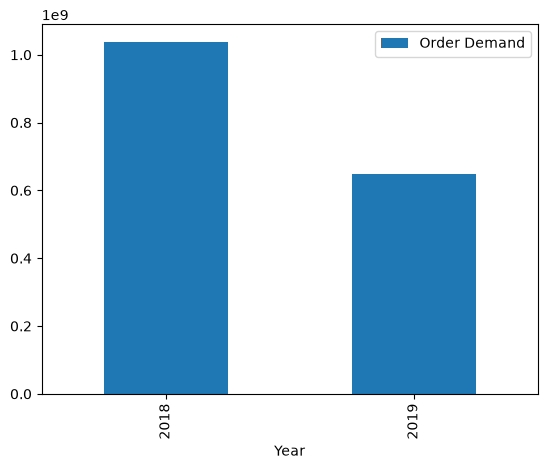

In [77]:
yearly_demand.plot.bar(
    x="Month",
    y="Order Demand"
)

plt.show()

In [141]:
monthly_demand = (
    df.assign(Month=df["Date"].dt.to_period("M"))
      .groupby("Month", as_index=True)["Order Demand"]
      .sum()
)

In [142]:
monthly_demand

Month
2018-01     64286498
2018-02     47002549
2018-03     85131534
2018-04     35217745
2018-05     54664706
2018-06     58967703
2018-07     65649493
2018-08     72673304
2018-09    137021451
2018-10    277573292
2018-11     84650170
2018-12     55374365
2019-01     67079456
2019-02     57566533
2019-03     58482664
2019-04     66774707
2019-05     62472581
2019-06     66221261
2019-07     49639046
2019-08     50388017
2019-09     58004282
2019-10     42728461
2019-11     39734781
2019-12     29856548
Freq: M, Name: Order Demand, dtype: int64

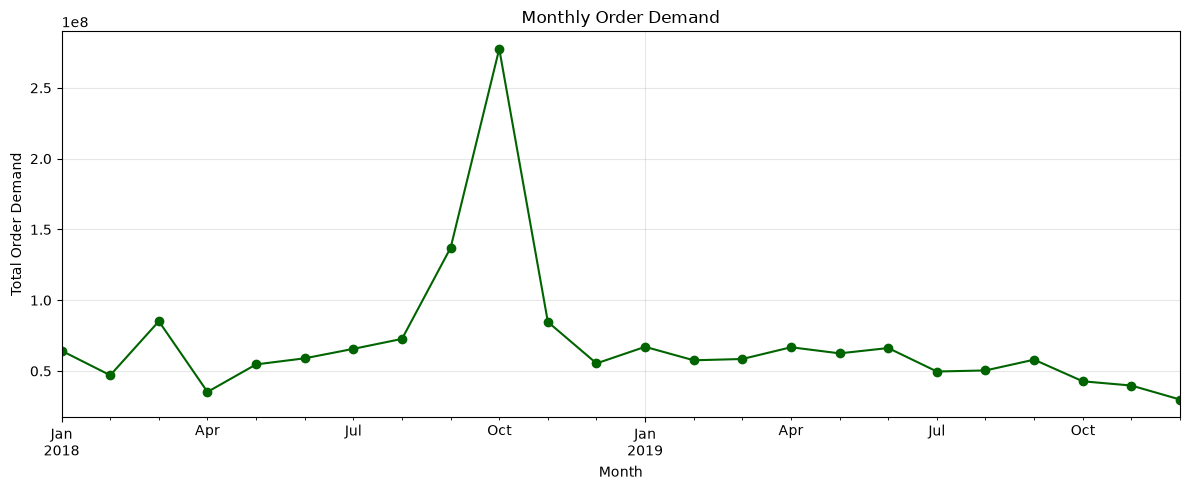

In [143]:
monthly_demand = (
    df.set_index("Date")["Order Demand"]
      .resample("MS")
      .sum()
)

plt.figure(figsize=(12, 5))

monthly_demand.plot(
    kind="line",
    marker="o",
    color="darkgreen"
)

plt.title("Monthly Order Demand")
plt.xlabel("Month")
plt.ylabel("Total Order Demand")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [109]:
daily_demand = (
    df.groupby("Date")["Order Demand"]
      .sum()
      .reset_index()
)

daily_demand["Day"] = daily_demand["Date"].dt.day_name()
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
weekly_pattern = (
    daily_demand.groupby("Day")["Order Demand"]
                .mean()
                .reindex(day_order)
)

print(weekly_pattern)

Day
Monday       4.001155e+06
Tuesday      3.760264e+06
Wednesday    3.841653e+06
Thursday     3.043758e+06
Friday       2.541454e+06
Saturday              NaN
Sunday                NaN
Name: Order Demand, dtype: float64


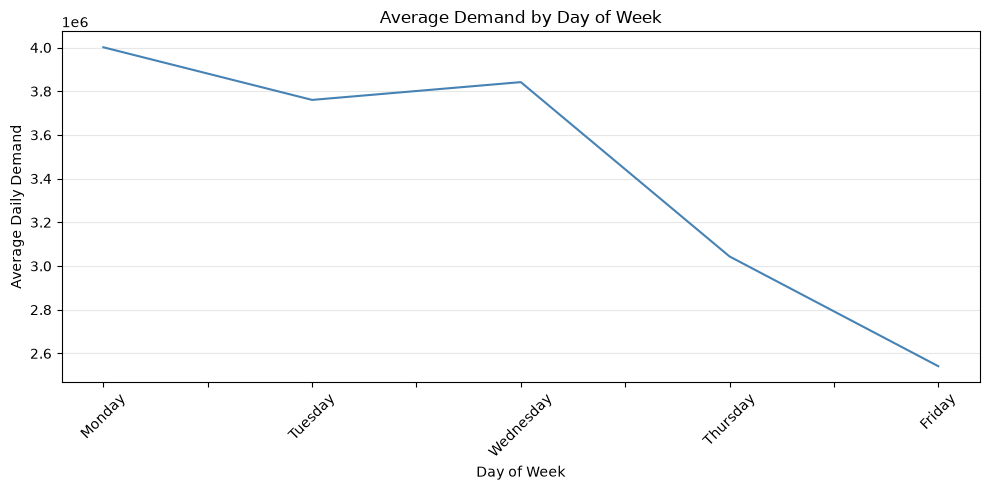

In [149]:
weekly_pattern.plot(
    kind="line",
    figsize=(10, 5),
    color="steelblue"
)

plt.title("Average Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Daily Demand")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [78]:
# demand across region

In [144]:
region_demand = (
    df.groupby("Zip",as_index=True)["Order Demand"]
      .sum()
)
print(region_demand)

Zip
17076      31103792
24701      56785681
78613    1246532479
94701     352739195
Name: Order Demand, dtype: int64


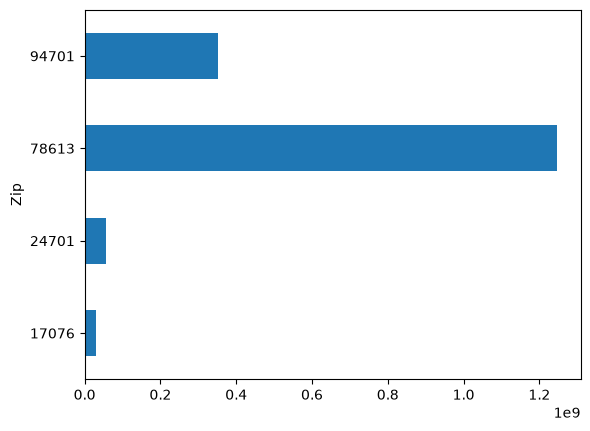

In [145]:
region_demand.plot.barh(
    x="Zip",
    y="Order Demand" 
)

plt.show()

In [146]:
warehouse_demand = (
    df.groupby("Warehouse", as_index=True)["Order Demand"]
      .sum()
)
print(warehouse_demand)

Warehouse
Berkeley          352739195
Cedar Park       1246532479
Montcalm           56785681
Oakland Mills      31103792
Name: Order Demand, dtype: int64


In [147]:
# 78163 - Cedar Park warehouse fulfilled the highest order demand 

In [115]:
# demand by category

In [134]:
category_demand = (
    df.groupby("Category", as_index=True)["Order Demand"]
      .sum()
)
print(category_demand)

Category
BI Stack           189655699
TBOX               174340813
Worksuite 1000    1323164635
Name: Order Demand, dtype: int64


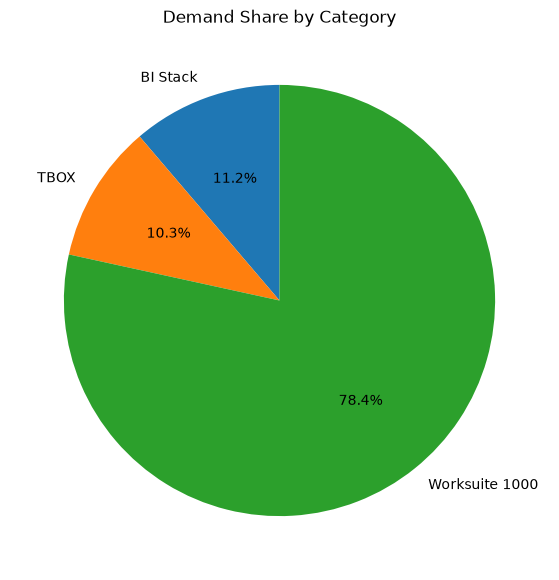

In [135]:
category_demand.plot.pie(
    y="Order Demand",
    figsize=(7, 7),
    autopct="%1.1f%%",
    startangle=90,
    legend=False
)

plt.title("Demand Share by Category")
plt.ylabel("")
plt.show()

In [84]:
# top-performing and underperforming products 

In [85]:
top_performing_products = (
    df.groupby("Product")["Order Demand"]
      .sum()
      .nlargest(10)
      .sort_values(ascending=False)
)
print(top_performing_products)

Product
TBOX             136830350
BI Visualiser    126114975
Sociplace        124695679
StorSQL          118564991
VideoRight       110754157
Whathype         108680512
Spreadcel         99620641
ShareIt           98947850
Streamer          90378644
Slackala          84667583
Name: Order Demand, dtype: int64


In [ ]:
# TBOX has the highest order demand 

In [86]:
top_underperforming_products = (
    df.groupby("Product")["Order Demand"]
      .sum()
      .nsmallest(10)
      .sort_values()
)
print(top_underperforming_products)

Product
BIApps          7414546
Interchange    21597450
EmailOut       24257903
FillForm       27936601
Tribes         29333281
PlanAhead      35346880
TBOX S3        37510463
QNote          40979309
MindVis        41237282
SlidePoint     41893965
Name: Order Demand, dtype: int64


In [ ]:
# BIApps has the lowest order demand 

In [87]:
# product revenue contribution and overall sales value

In [88]:
revenue = (
    df.groupby("Category", as_index=True)["Value"]
      .sum()
)

In [89]:
revenue

Category
BI Stack           1127210.46
TBOX               1497924.87
Worksuite 1000    13644846.84
Name: Value, dtype: float64

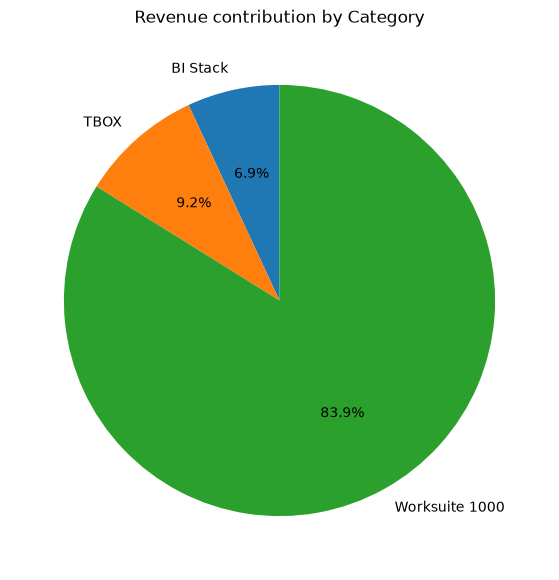

In [90]:
revenue.plot.pie(
    figsize=(7, 7),
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue contribution by Category")
plt.ylabel("")
plt.show()

In [91]:
revenue.sum()

np.float64(16269982.17)